In [ ]:
import os
import glob
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tifffile import imread
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm

BASE_DIR    = '/project/zhihuanglab/xuyinuo/enable_cell_data'
PATCH_DIR   = os.path.join(BASE_DIR, 'patches')
JSON_PATH   = os.path.join(BASE_DIR, 'cells.json')
PATCH_SIZE  = 224
HALF_SIZE   = PATCH_SIZE // 2

os.makedirs(PATCH_DIR, exist_ok=True)

region_dirs = [d for d in glob.glob(os.path.join(BASE_DIR, '*')) if os.path.isdir(d)]
# count H&E images
he_paths = [os.path.join(d, 'HandE.tif') for d in region_dirs if os.path.isfile(os.path.join(d, 'HandE.tif'))]
print(f'Total H&E images: {len(he_paths)}')
# count cells
total_cells = 0
for d in region_dirs:
    csv = os.path.join(d, os.path.basename(d) + '.cell_data.csv')
    if os.path.isfile(csv):
        total_cells += len(pd.read_csv(csv))
print(f'Total cells: {total_cells}')
# count annotation labels
label_counts = {}
for d in region_dirs:
    csv = os.path.join(d, os.path.basename(d) + '.cell_types.csv')
    if os.path.isfile(csv):
        for lab in pd.read_csv(csv)['ANNOTATION_LABEL']:
            label_counts[lab] = label_counts.get(lab, 0) + 1
print('Annotation label counts:')
for lab, cnt in label_counts.items():
    print(f'  {lab}: {cnt}')


Total H&E images: 1023
Total cells: 8533678
Annotation label counts:
  CD4 T cell: 170336
  Tumor (Podo+): 109880
  Tumor (Ki67+): 234849
  Macrophage: 185425
  Naive immune cell: 60654
  Vessel: 61019
  Unassigned: 137284
  Stromal / Fibroblast: 139577
  Tumor (CD15+): 112205
  Tumor: 199309
  Tumor (CD21+): 99552
  B cell: 116581
  CD8 T cell: 137328
  Granulocyte: 49901
  APC: 110931
  Tumor (CD20+): 38849
  Lymph vessel: 12293
  nan: 45349
  podocytes/lymphatic cells: 28916
  macrophages: 78481
  microcapillary cells: 72376
  stromal cells: 32663
  distal tubules: 49667
  proximal tubules atrophic: 26641
  CD4+ T cells: 78312
  CD8+ T cells: 78808
  proximal tubules activated: 43163
  Tregs: 158428
  proximal tubules: 91796
  B cells: 239416
  Gal3+Ecad+Epithelium: 255040
  Epithelium: 209746
  CD8+T cells: 19830
  Endothelial cells: 230098
  CD40+Macrophages: 13507
  Granulocytes: 136648
  Plasma cells: 192462
  Podoplanin+Stroma: 187905
  Stroma: 96089
  Col+MixedImmune: 42385
  

Extracting color patches:   0%|          | 0/4761 [00:00<?, ?it/s]

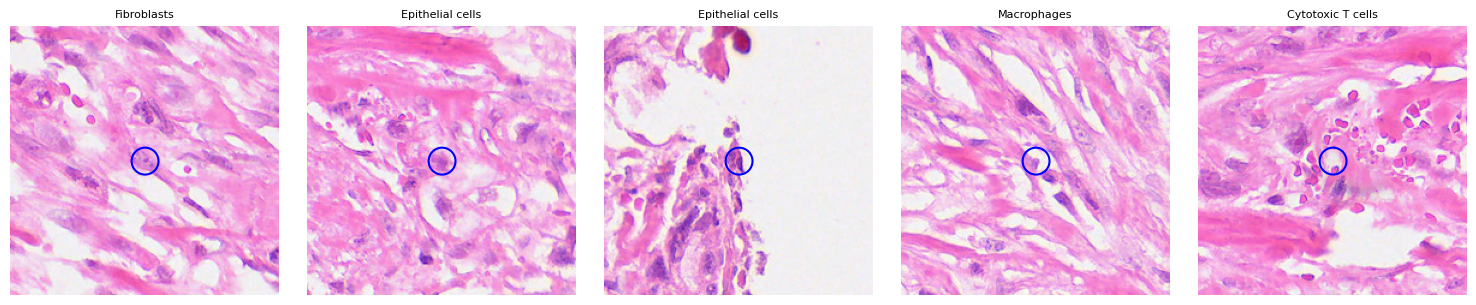

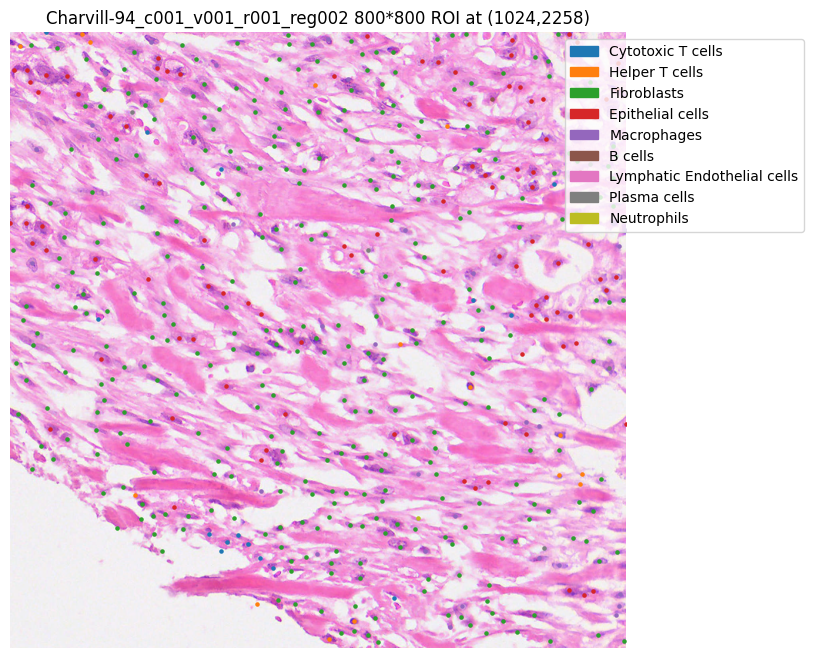

In [15]:
import os
import random
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tifffile import imread
from tqdm.auto import tqdm
from matplotlib.patches import Patch


BASE_DIR   = '/project/zhihuanglab/xuyinuo/enable_cell_data'
REGION_ID  = 'Charvill-94_c001_v001_r001_reg002'
REGION_DIR = os.path.join(BASE_DIR, REGION_ID)
DATA_CSV   = os.path.join(REGION_DIR, f'{REGION_ID}.cell_data.csv')
TYPES_CSV  = os.path.join(REGION_DIR, f'{REGION_ID}.cell_types.csv')
HE_PATH    = os.path.join(REGION_DIR, 'HandE.tif')
PATCH_DIR  = os.path.join(REGION_DIR, 'patches')
PATCH_SZ   = 224
HALF       = PATCH_SZ // 2
ROI_SIZE   = 800

os.makedirs(PATCH_DIR, exist_ok=True)


df_data  = pd.read_csv(DATA_CSV)
df_types = pd.read_csv(TYPES_CSV)
df       = df_data.merge(df_types[['CELL_ID','ANNOTATION_LABEL']],
                         on='CELL_ID', how='left')
img = imread(HE_PATH)

if img.ndim == 3 and img.shape[0] == 3:
    img = np.moveaxis(img, 0, -1)
H, W = img.shape[:2]


patch_files = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting color patches'):
    x, y = int(row['X']), int(row['Y'])
    x0, x1 = max(x-HALF, 0), min(x+HALF, W)
    y0, y1 = max(y-HALF, 0), min(y+HALF, H)
    p = img[y0:y1, x0:x1, :]  
    ph, pw = p.shape[:2]
    pad_h, pad_w = max(PATCH_SZ-ph, 0), max(PATCH_SZ-pw, 0)
    if pad_h or pad_w:
        
        p = np.pad(p,
                   ((0,pad_h),(0,pad_w),(0,0)),
                   mode='constant', constant_values=0)
    fname = f'{REGION_ID}_{row["CELL_ID"]:06d}.npy'
    path  = os.path.join(PATCH_DIR, fname)
    np.save(path, p)
    patch_files.append(path)

sample = random.sample(saved_patches, 5)
fig, axes = plt.subplots(1, 5, figsize=(15,3))
for ax, (fp, label) in zip(axes, sample):
    p = np.load(fp)
    ax.imshow(p.astype(float)/np.iinfo(p.dtype).max)
    # draw a blue circle at the center
    circ = Circle((HALF, HALF), radius=HALF*0.1,
                  edgecolor='blue', facecolor='none', linewidth=1.5)
    ax.add_patch(circ)
    ax.set_title(label, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

x0 = random.randint(0, max(W-ROI_SIZE, 0))
y0 = random.randint(0, max(H-ROI_SIZE, 0))
roi = img[y0:y0+ROI_SIZE, x0:x0+ROI_SIZE, :]


sel = df[(df['X'] >= x0) & (df['X'] < x0+ROI_SIZE) &
         (df['Y'] >= y0) & (df['Y'] < y0+ROI_SIZE)].copy()

sel['lx'] = sel['X'] - x0
sel['ly'] = sel['Y'] - y0


labels = sel['ANNOTATION_LABEL'].unique()
cmap   = plt.get_cmap('tab10')
colors = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.imshow(roi)
for lab, group in sel.groupby('ANNOTATION_LABEL'):
    ax.scatter(group['lx'], group['ly'],
               s=5, c=[colors[lab]], label=lab, marker='o')
ax.set_title(f'{REGION_ID} 800*800 ROI at ({x0},{y0})')
ax.axis('off')

handles = [Patch(color=colors[lab], label=lab) for lab in labels]
ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.3,1))
plt.show()
